
## Ejercicio 3: Datos faltantes y atípicos

Usa `co2_owid.csv`: emisiones de CO₂, CO₂ per cápita, población y PIB por país y año desde 1950.

**Faltantes**

1. Calcula conteo y % de faltantes por columna.
2. Filtra los renglones donde `iso_code` es faltante y revisa `country`. ¿Qué puedes cocnluir de este análisis?

**Atípicos**

3. Para **2020**, detecta atípicos de `co2_per_capita` con IQR. Lista los países y muestra un boxplot.
   

Alumno: Santiago Nuñez Perez


In [ ]:
# Configuración común
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dir_base = Path.cwd()
ruta = dir_base / "Data"

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


In [ ]:
datos_repaso = os.path.join(ruta, 'Datos_repaso')
salida = os.path.join(datos_repaso, 'salida')

In [ ]:
# 1.- Calcula conteo y % de faltantes por columna.

co2 = pd.read_csv(os.path.join(datos_repaso, "co2_owid.csv"))
display(pd.DataFrame({"faltantes": co2.isna().sum(), "%": (co2.isna().mean() * 100).round(2)}))


,faltantes,%
country,0,0.00
year,0,0.00
iso_code,2634,13.87
population,1809,9.53
gdp,7512,39.57
co2,1437,7.57
co2_per_capita,2491,13.12


In [ ]:
# 2.- Filtra los renglones donde iso_code es faltante y revisa country. ¿Qué puedes cocnluir de este análisis?
co2_sin_iso = co2[co2['iso_code'].isna()]

paises_sin_iso = co2_sin_iso['country'].unique()
print(paises_sin_iso)

['Africa' 'Africa (GCP)' 'Asia' 'Asia (GCP)'
 'Asia (excl. China and India)' 'Central America (GCP)' 'Europe'
 'Europe (GCP)' 'Europe (excl. EU-27)' 'Europe (excl. EU-28)'
 'European Union (27)' 'European Union (28)' 'High-income countries'
 'International aviation' 'International shipping' 'Kosovo'
 'Kuwaiti Oil Fires' 'Kuwaiti Oil Fires (GCP)'
 'Least developed countries (Jones et al.)' 'Low-income countries'
 'Lower-middle-income countries' 'Middle East (GCP)' 'Non-OECD (GCP)'
 'North America' 'North America (GCP)' 'North America (excl. USA)'
 'OECD (GCP)' 'OECD (Jones et al.)' 'Oceania' 'Oceania (GCP)'
 'Ryukyu Islands' 'Ryukyu Islands (GCP)' 'South America'
 'South America (GCP)' 'Upper-middle-income countries' 'World']


Se concluye que los datos sin código ISO no son países, sino territorios (como las islas Ryukyu), continentes o categorías económicas ("países de altos ingresos"). Su falta de código se debe a que pertenecen a una clasificación geopolítica diferente.Se concluye que los datos sin código ISO no son países, sino territorios (como las islas Ryukyu), continentes o categorías económicas ("países de altos ingresos"). Su falta de código se debe a que pertenecen a una clasificación geopolítica diferente.

Países/Regiones con emisiones atípicas en 2020:


,country,co2_per_capita
14127,Qatar,36.145
1570,Bahrain,25.238
2695,Brunei,24.937
17329,Trinidad and Tobago,23.661
17929,United Arab Emirates,22.783
15154,Saudi Arabia,21.089
8995,Kuwait,20.477
12027,New Caledonia,17.978
15604,Sint Maarten (Dutch part),15.897
13302,Oman,15.886


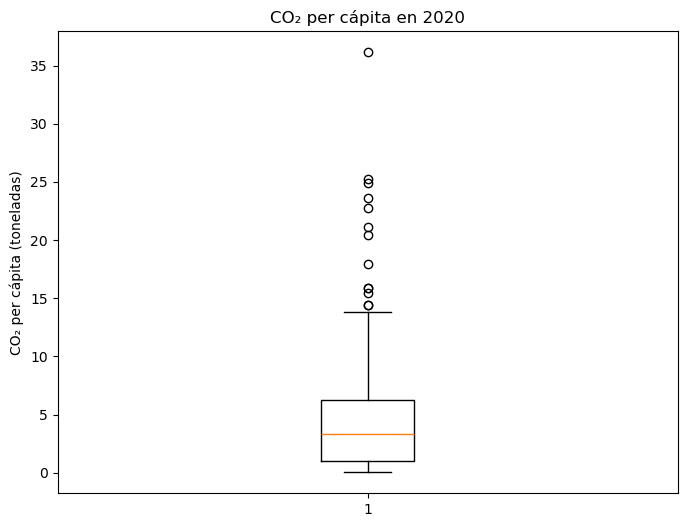

In [ ]:
# Para 2020, detecta atípicos de co2_per_capita con IQR. Lista los países y muestra un boxplot.

co2_2020 = co2[co2['year'] == 2020].copy()

co2_2020_limpio = co2_2020.dropna(subset=['co2_per_capita'])

#Calcular Q1, Q3 y el IQR
Q1 = co2_2020_limpio['co2_per_capita'].quantile(0.25)
Q3 = co2_2020_limpio['co2_per_capita'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos = co2_2020_limpio[
    (co2_2020_limpio['co2_per_capita'] < limite_inferior) | 
    (co2_2020_limpio['co2_per_capita'] > limite_superior)
]

print("Países/Regiones con emisiones atípicas en 2020:")
display(atipicos[['country', 'co2_per_capita']].sort_values(by='co2_per_capita', ascending=False))

# Boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(co2_2020_limpio['co2_per_capita'])
plt.title('CO₂ per cápita en 2020')
plt.ylabel('CO₂ per cápita (toneladas)')
plt.show()

Los datos muestran valores atípicos, principalmente en Qatar, el Medio Oriente y pequeñas islas. Esto se debe a su estructura económica: mientras que los primeros son grandes extractores de minerales e hidrocarburos, los países insulares dependen de importar estos combustibles para generar energía.